In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Multivariate Normal Distribution

$\mathbf{x} \in \mathbb{R}^d$ - variable vector at which the PDF is evaluated

$\Sigma \in \mathbb{R}^{d \times d}$ - covariance matrix, determines the spread and correlation of data

$\mathbf{\mu} \in \mathbb{R}^d$ - mean vector, determines the center of distribution

$ \left | \Sigma \right |$ - determinant of covariance matrix

$\Sigma^{-1}$ - inverse of covariance matrix

$$

\text{Probability density function} = \frac{1}{\sqrt{(2 \pi)^d \cdot \left | \Sigma \right |}} \exp \left(- \frac{1}{2} (\mathbf{x} - \mathbf{\mu})^{\text{T}} \Sigma^{-1} (\mathbf{x} - \mathbf{\mu}) \right) \\

$$

***

# Covariance matrix criteria for positive definiteness

For $2 \times 2$ covariance matrix with $a = \sigma^2_x$, $b = \sigma_x \sigma_y$, $c = \sigma^2_y$

$$
\Sigma = \begin{bmatrix}
a & b \\
b & c
\end{bmatrix}
$$

the following criteria must be satisfied:


\begin{align}

\text{Strictly positive diagonal} &\Rightarrow a > 0, c > 0 \\
\text{Strictly positive determinant}&\Rightarrow \left | \Sigma \right | > 0 \Rightarrow ac > b^2

\end{align}

***

# Random sample from multivariate normal distribution

- generate *d* dimensional vector $\mathbf{z}$ with independent entries from univariate standard normal distribution $\mathcal{N}(0, 1)$

- Cholesky decompose the covariance matrix $\Sigma = \mathbf{L}\mathbf{L}^{\text{T}}$ (make sure the covariance matrix is positive definite)

- transform the sample: $\mathbf{x} = \mathbf{L}\mathbf{z} + \mu$

In [2]:
def generate_multivariate_random_normal(mu, cov, n_samples=1):

    d = len(mu)
    z = np.random.standard_normal((n_samples, d))
    L = np.linalg.cholesky(cov)
    x = np.dot(z, L) + mu
    return x

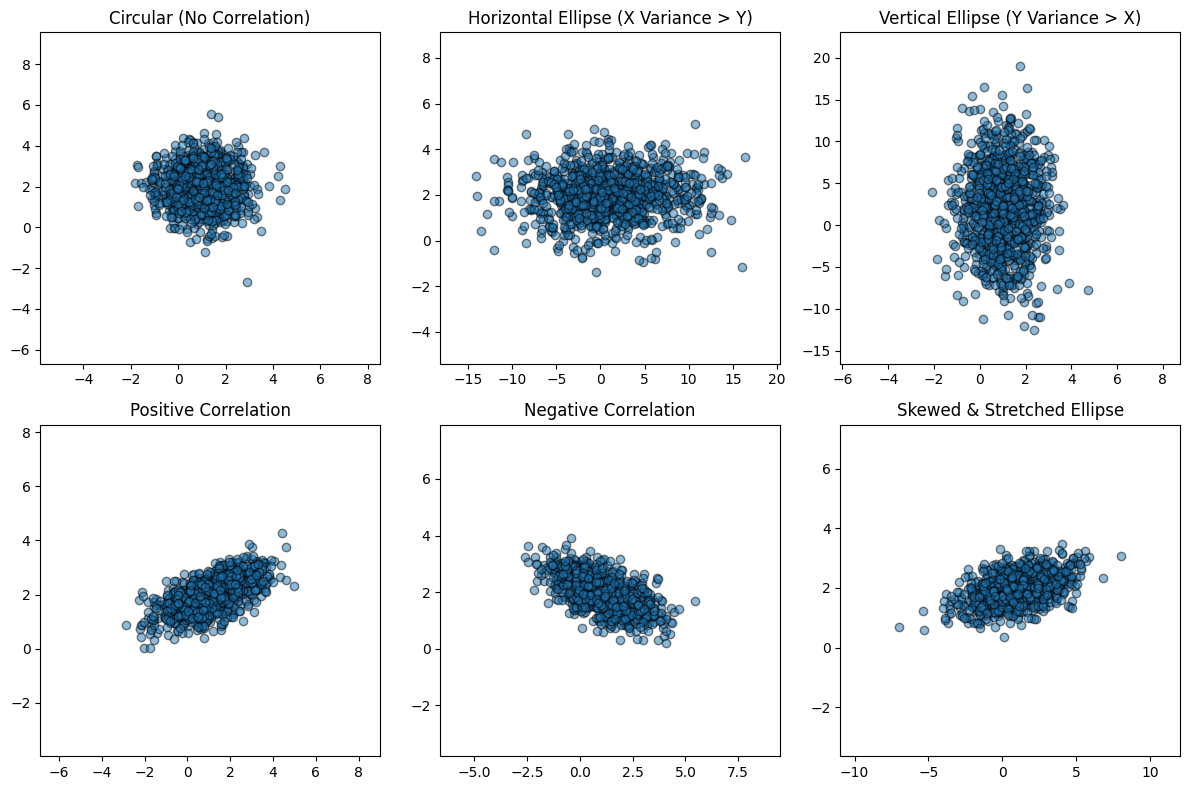

In [3]:
mu = np.array([1, 2])
N = 1000

covariances = [
    (np.array([[1, 0], [0, 1]]), "Circular (No Correlation)"),
    (np.array([[25, 0], [0, 1]]), "Horizontal Ellipse (X Variance > Y)"),
    (np.array([[1, 0], [0, 25]]), "Vertical Ellipse (Y Variance > X)"),
    (np.array([[1, 0.8], [0.8, 1]]), "Positive Correlation"),
    (np.array([[1, -0.8], [-0.8, 1]]), "Negative Correlation"),
    (np.array([[3, 1.5], [1.5, 1]]), "Skewed & Stretched Ellipse"),
]

plt.figure(figsize=(12, 8))

for i, (cov, title) in enumerate(covariances, 1):
    X = generate_multivariate_random_normal(mu, cov, N)
    ax = plt.subplot(2, 3, i)
    ax.scatter(X[:, 0], X[:, 1], alpha=0.5, edgecolor="black")
    ax.set_title(title)
    padding = 4
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()

    x_center = mu[0]
    y_center = mu[1]

    ax.set_xlim(min(x_min, x_center) - padding, max(x_max, x_center) + padding)
    ax.set_ylim(min(y_min, y_center) - padding, max(y_max, y_center) + padding)

plt.tight_layout()
plt.show()
